# 0_2. Topologia i geometria grafu sąsiedztwa — ręcznie

Ten notebook jest naturalną kontynuacją notebooka **0_1**.

W `0_1` zbudowaliśmy graf:

```text
punkty → odległości → sąsiedztwo → graf
```

Tutaj zadajemy następne pytanie:

> Skoro mamy już graf, to co możemy o nim zmierzyć?

Będziemy pracować nadal na tych samych punktach `A, B, C, D, E, F`, ale tym razem interesują nas własności grafu:

1. **stopień wierzchołka**,
2. **liczba krawędzi**,
3. **składowe spójne**,
4. **odległości grafowe**,
5. **lokalne klastrowanie**,
6. **lokalny wzrost kul grafowych**,
7. intuicja: co to znaczy, że graf jest bardziej „zwarty”, „płaski” albo „drzewiasty”.

To jeszcze nie jest formalna krzywizna dyskretna. To jest przygotowanie intuicji pod późniejsze tematy: **UMAP**, **DBSCAN**, spectral clustering, Graph Neural Networks i analizę geometrii embeddingów.


## Gdzie wstawić ten notebook w kursie?

Najlepsze miejsce:

```text
0_1_odległości_macierze_sąsiedztwa_kNN
↓
0_2_topologia_i_geometria_grafu
↓
2_4_similarity_scores_UMAP_tSNE
↓
2_3_UMAP_ręcznie
```

Dlaczego **po 0_1**, a nie dopiero po UMAP?

Bo UMAP, DBSCAN i metody grafowe korzystają z grafu sąsiedztwa. Najpierw warto więc nauczyć się czytać sam graf: ile ma krawędzi, czy jest spójny, jakie ma lokalne zagęszczenia i jak mierzyć odległość po grafie.


## Co już znamy?

Z poprzedniego notebooka znamy:

- macierz danych $X$,
- macierz odległości $D$,
- macierz sąsiedztwa $A$,
- graf sąsiedztwa $G=(V,E)$,
- graf $\varepsilon$-sąsiedztwa,
- graf $k$NN,
- symetryzację `union/OR` i `mutual/AND`.

## Czego użyjemy dzisiaj?

Wejście:

$$
X \in \mathbb{R}^{n\times d}
$$

Budujemy:

$$
D_{ij}=d(x_i,x_j)
$$

oraz macierz sąsiedztwa:

$$
A_{ij}\in\{0,1\}.
$$

Potem mierzymy własności grafu opisanego przez $A$.


## 0. Importy i ustawienia

Tak jak w notebooku `0_1`, nie używamy niestabilnego `df.style.format(...)`. Tabele pokazujemy jako zwykłe `DataFrame`, żeby uniknąć dziwnych problemów z renderowaniem.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

np.set_printoptions(precision=3, suppress=True)
pd.set_option('display.precision', 3)

plt.rcParams['figure.figsize'] = (7, 5)
plt.rcParams['axes.grid'] = True


## 0.1. Funkcje pomocnicze: odległości, sąsiedztwo i grafy

Te funkcje są prawie takie same jak w `0_1`.

Najważniejsze obiekty:

$$
D_{ij}=d(x_i,x_j)
$$

oraz

$$
A_{ij}=1
$$

gdy między punktami $i$ oraz $j$ istnieje krawędź.


In [2]:
def pairwise_distances(X):
    # Liczy macierz odległości euklidesowych między wszystkimi parami punktów.
    X = np.asarray(X, dtype=float)
    diff = X[:, None, :] - X[None, :, :]
    return np.sqrt((diff ** 2).sum(axis=2))


def adjacency_eps(D, eps):
    # Macierz epsilon-sąsiedztwa: 1, gdy 0 < D_ij <= eps.
    D = np.asarray(D, dtype=float)
    return ((D <= eps) & (D > 0)).astype(int)


def knn_adjacency(D, k):
    # Kierunkowa macierz kNN: każdy punkt wskazuje k najbliższych sąsiadów.
    D = np.asarray(D, dtype=float)
    n = D.shape[0]
    A = np.zeros((n, n), dtype=int)
    for i in range(n):
        order = np.argsort(D[i])
        order = order[order != i]
        neigh = order[:k]
        A[i, neigh] = 1
    return A


def sym_union(A):
    # Symetryzacja union/OR: wystarczy relacja w jedną stronę.
    A = np.asarray(A, dtype=int)
    return np.maximum(A, A.T)


def sym_mutual(A):
    # Symetryzacja mutual/AND: relacja musi być wzajemna.
    A = np.asarray(A, dtype=int)
    return np.minimum(A, A.T)


def format_matrix_for_display(M, labels, number_format='.0f'):
    # Stabilne wyświetlanie macierzy bez Stylera i bez NaN/N/A.
    M = np.asarray(M)
    rows = []
    for i in range(M.shape[0]):
        row = []
        for j in range(M.shape[1]):
            value = M[i, j]
            if isinstance(value, str):
                row.append(value)
            elif np.isinf(value):
                row.append('∞')
            elif number_format == '.0f':
                row.append(f'{float(value):.0f}')
            elif number_format == '.1f':
                row.append(f'{float(value):.1f}')
            elif number_format == '.3f':
                row.append(f'{float(value):.3f}')
            else:
                row.append(f'{float(value):.2f}')
        rows.append(row)
    return pd.DataFrame(rows, index=labels, columns=labels)


## 0.2. Funkcje pomocnicze: rysowanie grafu

Macierz sąsiedztwa $A$ jest tabelą zer i jedynek.

Funkcja `plot_graph(...)` zamienia ją na obrazek:

- jeśli $A_{ij}=1$, rysujemy krawędź,
- jeśli $A_{ij}=0$, krawędzi nie ma.


In [3]:
def plot_points(X, labels, title='punkty', ax=None, annotate=True):
    X = np.asarray(X, dtype=float)
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4.5))
    ax.scatter(X[:, 0], X[:, 1], s=110)
    if annotate:
        for lab, (xv, yv) in zip(labels, X):
            ax.text(xv + 0.04, yv + 0.04, str(lab), fontsize=11, weight='bold')
    ax.set_title(title)
    ax.set_aspect('equal', adjustable='box')
    return ax


def plot_graph(X, labels, A, title='', ax=None, values=None, value_label=''):
    X = np.asarray(X, dtype=float)
    A = np.asarray(A, dtype=int)
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4.5))

    ax.scatter(X[:, 0], X[:, 1], s=130)

    n = len(labels)
    for i in range(n):
        for j in range(i + 1, n):
            if A[i, j] == 1:
                ax.plot([X[i, 0], X[j, 0]], [X[i, 1], X[j, 1]], alpha=0.55, lw=1.6)

    for i, lab in enumerate(labels):
        ax.text(X[i, 0] + 0.04, X[i, 1] + 0.04, str(lab), fontsize=11, weight='bold')
        if values is not None:
            ax.text(
                X[i, 0] + 0.04,
                X[i, 1] - 0.22,
                f'{value_label}{values[i]}',
                fontsize=9
            )

    ax.set_title(title)
    ax.set_aspect('equal', adjustable='box')
    return ax


def edge_list_df(A, labels):
    # Lista krawędzi grafu nieskierowanego.
    A = np.asarray(A, dtype=int)
    edges = []
    n = len(labels)
    for i in range(n):
        for j in range(i + 1, n):
            if A[i, j] == 1:
                edges.append((labels[i], labels[j]))
    return pd.DataFrame(edges, columns=['początek', 'koniec'])


## 0.3. Dane: te same punkty co w `0_1`

Celowo używamy tych samych danych, żeby kontynuacja była naturalna.

Mamy dwie lokalne grupy:

```text
A, B, C        D, E, F
```

Dzięki temu dobrze widać, kiedy graf ma dwie składowe, a kiedy parametry tworzą most między grupami.


,x,y
A,0.0,0.0
B,0.5,0.2
C,1.1,0.1
D,4.0,3.8
E,4.6,4.1
F,5.0,3.6


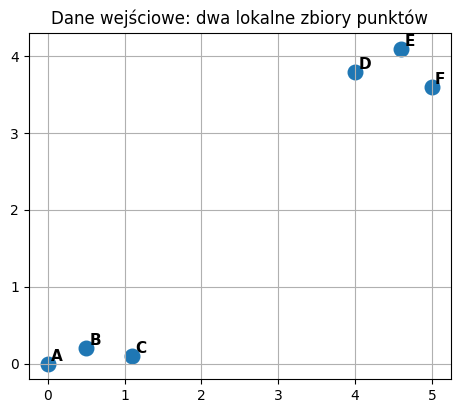

In [4]:
labels = np.array(list('ABCDEF'))

X = np.array([
    [0.0, 0.0],   # A
    [0.5, 0.2],   # B
    [1.1, 0.1],   # C
    [4.0, 3.8],   # D
    [4.6, 4.1],   # E
    [5.0, 3.6],   # F
])

D = pairwise_distances(X)

points_df = pd.DataFrame(X, index=labels, columns=['x', 'y'])
display(points_df)

plot_points(X, labels, title='Dane wejściowe: dwa lokalne zbiory punktów')
plt.show()


## 1. Zbudujmy dwa grafy referencyjne

Będziemy często porównywać dwa grafy:

1. graf `union` dla $k=2$,
2. graf `union` dla $k=3$.

Dlaczego akurat te dwa?

Dla $k=2$ każdy punkt ma w swojej lokalnej grupie dwóch naturalnych sąsiadów. Graf powinien zachować dwie oddzielne grupy.

Dla $k=3$ każdy punkt musi dobrać trzeciego sąsiada, więc pojawiają się połączenia między grupami.


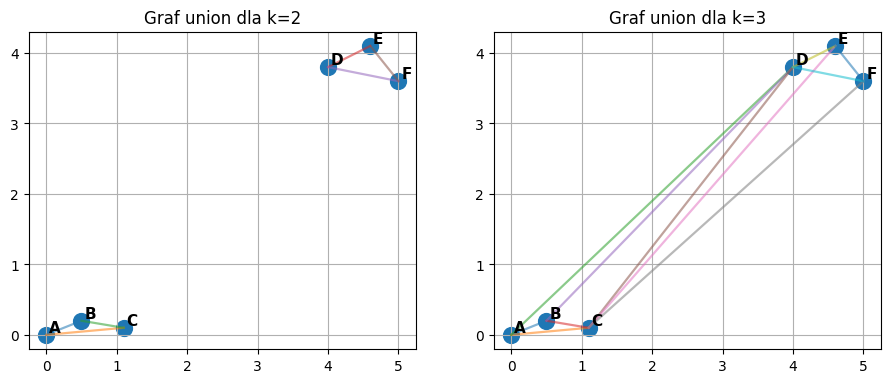

### Macierz sąsiedztwa dla k=2

,A,B,C,D,E,F
A,0,1,1,0,0,0
B,1,0,1,0,0,0
C,1,1,0,0,0,0
D,0,0,0,0,1,1
E,0,0,0,1,0,1
F,0,0,0,1,1,0


### Macierz sąsiedztwa dla k=3

,A,B,C,D,E,F
A,0,1,1,1,0,0
B,1,0,1,1,0,0
C,1,1,0,1,1,1
D,1,1,1,0,1,1
E,0,0,1,1,0,1
F,0,0,1,1,1,0


In [5]:
A_k2 = sym_union(knn_adjacency(D, k=2))
A_k3 = sym_union(knn_adjacency(D, k=3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
plot_graph(X, labels, A_k2, title='Graf union dla k=2', ax=axes[0])
plot_graph(X, labels, A_k3, title='Graf union dla k=3', ax=axes[1])
plt.show()

display(Markdown('### Macierz sąsiedztwa dla k=2'))
display(format_matrix_for_display(A_k2, labels, number_format='.0f'))

display(Markdown('### Macierz sąsiedztwa dla k=3'))
display(format_matrix_for_display(A_k3, labels, number_format='.0f'))


### Minićwiczenie 1 — zanim przejdziesz dalej

Spójrz na dwa grafy powyżej.

1. Dla którego grafu mamy dwie oddzielne części: `ABC` oraz `DEF`?
2. Dla którego grafu pojawia się most między grupami?
3. Czy większe $k$ zawsze oznacza „lepszy” graf?


### Rozwiązanie minićwiczenia 1

1. Dla $k=2$ graf zachowuje dwie oddzielne grupy.
2. Dla $k=3$ pojawia się połączenie między grupami.
3. Nie. Większe $k$ daje więcej krawędzi, ale może też wymusić połączenia między punktami, które geometrycznie są daleko od siebie.

Najważniejszy wniosek:

> Parametr $k$ zmienia nie tylko liczbę sąsiadów, ale też topologię grafu.


## 1a. Od grafu kNN do rozmytego (fuzzy) grafu sąsiedztwa

Do tej pory graf był **binarny**:

$$
A_{ij}\in\{0,1\}.
$$

To znaczy:

- `1` — między punktami jest krawędź,
- `0` — krawędzi nie ma.

W metodach takich jak **UMAP** używamy bardziej miękkiej wersji tego pomysłu.

Zamiast pytać tylko:

> Czy punkt $j$ jest sąsiadem punktu $i$?

pytamy:

> Jak silnym sąsiadem punktu $i$ jest punkt $j$?

Dlatego zamiast macierzy zer i jedynek dostajemy macierz wag:

$$
0 \leq \mu_{ij} \leq 1.
$$

Interpretacja jest prosta:

- $\mu_{ij}\approx 1$ — bardzo silne lokalne połączenie,
- $\mu_{ij}\approx 0.5$ — umiarkowane połączenie,
- $\mu_{ij}\approx 0$ — bardzo słabe połączenie.

To jest intuicja stojąca za pojęciem **fuzzy graph of neighborhoods**.

W pełnym UMAP ta konstrukcja jest opisywana jako **fuzzy simplicial set**. Na tym etapie kursu możemy myśleć o niej po prostu jako o **ważonym, rozmytym grafie sąsiedztwa**.

### Binarna macierz sąsiedztwa dla k=3

,A,B,C,D,E,F
A,0,1,1,1,0,0
B,1,0,1,1,0,0
C,1,1,0,1,1,1
D,1,1,1,0,1,1
E,0,0,1,1,0,1
F,0,0,1,1,1,0


### Rozmyta macierz sąsiedztwa dla k=3

,A,B,C,D,E,F
A,0.000,1.000,0.820,0.008,0.000,0.000
B,1.000,0.000,1.000,0.000,0.000,0.000
C,0.820,1.000,0.000,0.012,0.000,0.001
D,0.008,0.000,0.012,0.000,1.000,0.826
E,0.000,0.000,0.000,1.000,0.000,1.000
F,0.000,0.000,0.001,0.826,1.000,0.000


### Lokalne skale użyte do rozmycia grafu

,punkt,rho_i: odległość do najbliższego sąsiada,sigma_i: lokalna skala
0,A,0.539,1.029
1,B,0.539,0.130
2,C,0.608,0.896
3,D,0.671,0.647
4,E,0.640,0.057
5,F,0.640,0.704


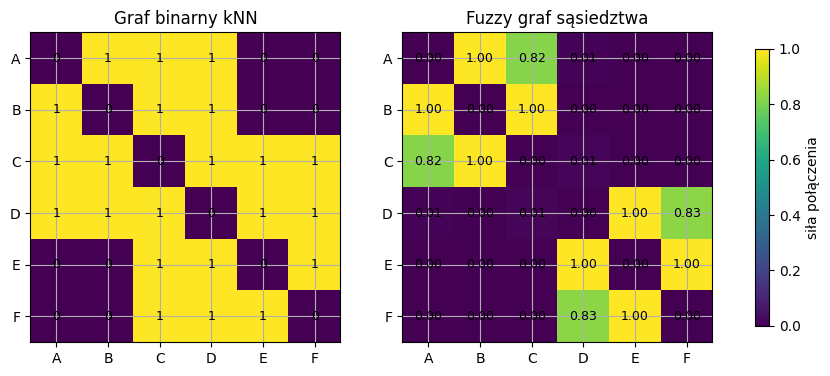

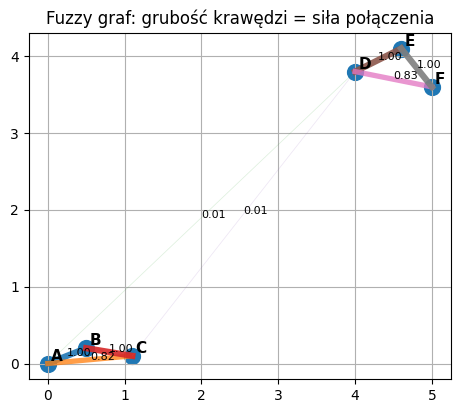

In [6]:
def smooth_knn_fuzzy_graph(D, k=3, n_iter=64):
    """
    Uproszczona, dydaktyczna wersja konstrukcji fuzzy grafu sąsiedztwa.

    Krok 1.
    Dla każdego punktu bierzemy k najbliższych sąsiadów.

    Krok 2.
    Najbliższy sąsiad dostaje wagę bliską 1.

    Krok 3.
    Dalsi sąsiedzi dostają coraz mniejsze wagi.

    Krok 4.
    Graf kierunkowy symetryzujemy operacją fuzzy union:
        w_ij = v_{j|i} + v_{i|j} - v_{j|i} v_{i|j}

    To nie jest pełna implementacja UMAP, ale pokazuje ten sam
    kluczowy pomysł: przejście od grafu 0/1 do grafu z wagami [0,1].
    """
    D = np.asarray(D, dtype=float)
    n = D.shape[0]

    order = np.argsort(D, axis=1)
    neighbors = order[:, 1:k + 1]
    knn_dists = np.take_along_axis(D, neighbors, axis=1)

    # rho_i: lokalna odległość do najbliższego sąsiada.
    # Dzięki temu najbliższy sąsiad ma bardzo silne połączenie.
    rho = knn_dists[:, 0].copy()

    # W UMAP skala sigma_i jest dobierana lokalnie.
    # Tu dobieramy ją prostym binary search tak, aby suma wag była podobna
    # do log2(k), czyli do efektywnej liczby lokalnych sąsiadów.
    target = np.log2(k)
    sigmas = np.zeros(n)
    V_directed = np.zeros((n, n), dtype=float)

    for i in range(n):
        adjusted = np.maximum(0.0, knn_dists[i] - rho[i])

        def membership_sum(sigma):
            sigma = max(float(sigma), 1e-12)
            return np.exp(-adjusted / sigma).sum()

        lo, hi = 0.0, 1.0
        while membership_sum(hi) < target and hi < 1e6:
            hi *= 2.0

        for _ in range(n_iter):
            mid = (lo + hi) / 2.0
            if membership_sum(mid) > target:
                hi = mid
            else:
                lo = mid

        sigmas[i] = hi
        V_directed[i, neighbors[i]] = np.exp(-adjusted / max(sigmas[i], 1e-12))

    # Fuzzy union: jeśli relacja jest silna w jedną albo drugą stronę,
    # to połączenie w grafie nieskierowanym też jest silne.
    W = V_directed + V_directed.T - V_directed * V_directed.T
    np.fill_diagonal(W, 0.0)

    return neighbors, rho, sigmas, V_directed, W


k_fuzzy = 3
neighbors_fuzzy, rho_fuzzy, sigma_fuzzy, V_fuzzy_directed, W_fuzzy = smooth_knn_fuzzy_graph(D, k=k_fuzzy)

A_k3_binary = sym_union(knn_adjacency(D, k=k_fuzzy))

display(Markdown(f"### Binarna macierz sąsiedztwa dla k={k_fuzzy}"))
display(format_matrix_for_display(A_k3_binary, labels, number_format='.0f'))

display(Markdown(f"### Rozmyta macierz sąsiedztwa dla k={k_fuzzy}"))
display(format_matrix_for_display(W_fuzzy, labels, number_format='.3f'))

local_scales_df = pd.DataFrame({
    "punkt": labels,
    "rho_i: odległość do najbliższego sąsiada": rho_fuzzy,
    "sigma_i: lokalna skala": sigma_fuzzy,
})
display(Markdown("### Lokalne skale użyte do rozmycia grafu"))
display(local_scales_df.round(3))


def plot_matrix_with_numbers(M, labels, title, ax=None):
    M = np.asarray(M, dtype=float)
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))

    im = ax.imshow(M, vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)

    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            value = M[i, j]
            text = f"{value:.0f}" if np.all((M == 0) | (M == 1)) else f"{value:.2f}"
            ax.text(j, i, text, ha="center", va="center", fontsize=9)

    return im


fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
plot_matrix_with_numbers(A_k3_binary, labels, "Graf binarny kNN", ax=axes[0])
im = plot_matrix_with_numbers(W_fuzzy, labels, "Fuzzy graf sąsiedztwa", ax=axes[1])
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8, label="siła połączenia")
plt.show()


def plot_weighted_graph(X, labels, W, title='', min_weight=0.005):
    X = np.asarray(X, dtype=float)
    W = np.asarray(W, dtype=float)

    fig, ax = plt.subplots(figsize=(6, 4.5))
    ax.scatter(X[:, 0], X[:, 1], s=130)

    n = len(labels)
    for i in range(n):
        for j in range(i + 1, n):
            weight = W[i, j]
            if weight > min_weight:
                ax.plot(
                    [X[i, 0], X[j, 0]],
                    [X[i, 1], X[j, 1]],
                    alpha=0.15 + 0.75 * weight,
                    lw=0.5 + 4.0 * weight,
                )
                mid = (X[i] + X[j]) / 2
                ax.text(mid[0], mid[1], f"{weight:.2f}", fontsize=8)

    for i, lab in enumerate(labels):
        ax.text(X[i, 0] + 0.04, X[i, 1] + 0.04, str(lab), fontsize=11, weight='bold')

    ax.set_title(title)
    ax.set_aspect('equal', adjustable='box')
    return ax


plot_weighted_graph(X, labels, W_fuzzy, title="Fuzzy graf: grubość krawędzi = siła połączenia")
plt.show()

### Co się zmieniło?

W grafie binarnym wszystkie zaakceptowane krawędzie wyglądają tak samo:

$$
A_{ij}=1.
$$

Nie widzimy więc różnicy między:

- sąsiadem bardzo bliskim,
- sąsiadem wymuszonym przez parametr $k$,
- słabym mostem między dwiema grupami.

W grafie fuzzy ta różnica jest widoczna od razu.

Dwie lokalne grupy `A-B-C` oraz `D-E-F` mają mocne połączenia, a most między grupami ma dużo mniejszą wagę.

To jest bardzo ważna intuicja przed UMAP:

> UMAP nie chce tylko wiedzieć, kto jest sąsiadem.  
> UMAP chce wiedzieć, **jak silne** jest lokalne sąsiedztwo.

### Most do t-SNE i UMAP

To miejsce łączy wcześniejsze notebooki z kolejnymi metodami redukcji wymiaru.

t-SNE buduje macierz:

$$
P_{ij}
$$

czyli probabilistyczny opis sąsiedztwa.

UMAP buduje macierz:

$$
\mu_{ij}
$$

czyli rozmyty opis sąsiedztwa.

W obu przypadkach pierwszy krok jest bardzo podobny dydaktycznie:

```text
punkty
↓
odległości
↓
lokalne sąsiedztwa
↓
macierz podobieństwa / graf z wagami
↓
nowe ułożenie punktów w 2D
```

Różnica jest w szczegółach matematycznych i w funkcji celu, ale intuicja jest wspólna:

> najpierw opisujemy lokalną strukturę danych, a potem próbujemy zachować ją po redukcji wymiaru.

## 2. Stopień wierzchołka

Pierwsza i najprostsza lokalna cecha grafu to **stopień wierzchołka**.

Dla grafu nieskierowanego:

$$
\deg(i)=\sum_j A_{ij}.
$$

Interpretacja:

> Ile sąsiadów ma punkt $i$?

- duży stopień — punkt jest dobrze połączony,
- mały stopień — punkt jest bardziej peryferyjny,
- stopień $0$ — punkt izolowany.


### Statystyki grafu dla k=2

,liczba wierzchołków,liczba krawędzi,minimalny stopień,średni stopień,maksymalny stopień
0,6,6,2,2.0,2


,punkt,stopień deg(i)
0,A,2
1,B,2
2,C,2
3,D,2
4,E,2
5,F,2


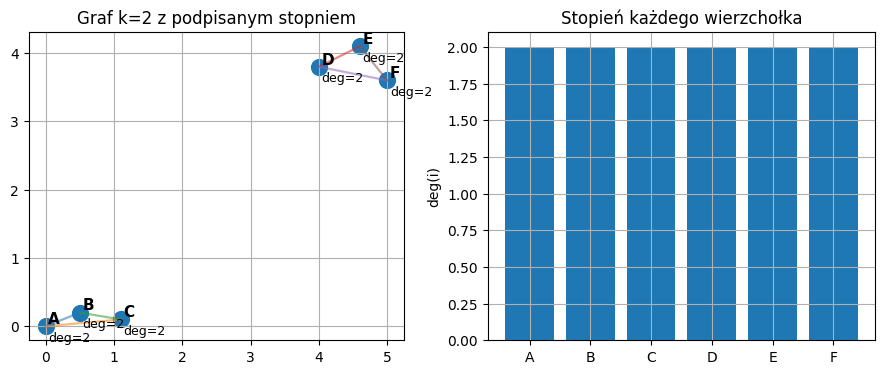

In [7]:
def degree_table(A, labels):
    A = np.asarray(A, dtype=int)
    degrees = A.sum(axis=1).astype(int)
    return pd.DataFrame({'punkt': labels, 'stopień deg(i)': degrees})


def graph_basic_stats(A, labels):
    A = np.asarray(A, dtype=int)
    degrees = A.sum(axis=1).astype(int)
    n_vertices = A.shape[0]
    n_edges = int(np.triu(A, 1).sum())
    return {
        'liczba wierzchołków': n_vertices,
        'liczba krawędzi': n_edges,
        'minimalny stopień': int(degrees.min()),
        'średni stopień': float(np.round(degrees.mean(), 3)),
        'maksymalny stopień': int(degrees.max())
    }

stats_k2 = graph_basic_stats(A_k2, labels)
stats_k3 = graph_basic_stats(A_k3, labels)

display(Markdown('### Statystyki grafu dla k=2'))
display(pd.DataFrame([stats_k2]))
display(degree_table(A_k2, labels))

degrees_k2 = A_k2.sum(axis=1).astype(int)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_graph(X, labels, A_k2, title='Graf k=2 z podpisanym stopniem', ax=axes[0], values=degrees_k2, value_label='deg=')
axes[1].bar(labels, degrees_k2)
axes[1].set_title('Stopień każdego wierzchołka')
axes[1].set_ylabel('deg(i)')
plt.show()


### Minićwiczenie 2 — stopień

Dla grafu `union` przy $k=2$ odpowiedz:

1. Jaki stopień ma punkt `A`?
2. Jaki stopień ma punkt `B`?
3. Czy wszystkie punkty mają taki sam stopień?
4. Co mówi nam to o strukturze grafu?


### Rozwiązanie minićwiczenia 2

Dla $k=2$ graf składa się z dwóch trójkątów: `A-B-C` oraz `D-E-F`.

Każdy punkt w trójkącie ma dokładnie dwóch sąsiadów, więc:

$$
\deg(A)=\deg(B)=\deg(C)=\deg(D)=\deg(E)=\deg(F)=2.
$$

Wniosek:

> Graf jest lokalnie bardzo regularny: każdy punkt ma tyle samo sąsiadów.


## 3. Liczba krawędzi i gęstość grafu

Liczba krawędzi mówi, ile połączeń ma graf.

Dla grafu nieskierowanego z macierzą symetryczną $A$:

$$
|E|=\frac{1}{2}\sum_{i,j} A_{ij}.
$$

Dzielimy przez $2$, bo każda krawędź występuje w macierzy dwa razy:

$$
A_{ij}=1
$$

i

$$
A_{ji}=1.
$$


,k,krawędzie union,krawędzie mutual,średni stopień union,średni stopień mutual
0,1,4,2,1.333,0.667
1,2,6,6,2.000,2.000
2,3,11,7,3.667,2.333
3,4,14,10,4.667,3.333
4,5,15,15,5.000,5.000


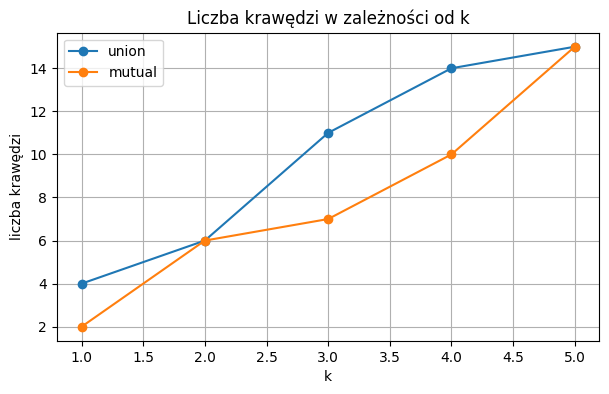

In [8]:
comparison_edges = []
for k in [1, 2, 3, 4, 5]:
    A_dir = knn_adjacency(D, k)
    A_u = sym_union(A_dir)
    A_m = sym_mutual(A_dir)
    comparison_edges.append({
        'k': k,
        'krawędzie union': int(np.triu(A_u, 1).sum()),
        'krawędzie mutual': int(np.triu(A_m, 1).sum()),
        'średni stopień union': float(np.round(A_u.sum(axis=1).mean(), 3)),
        'średni stopień mutual': float(np.round(A_m.sum(axis=1).mean(), 3)),
    })

edge_comparison_df = pd.DataFrame(comparison_edges)
display(edge_comparison_df)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(edge_comparison_df['k'], edge_comparison_df['krawędzie union'], marker='o', label='union')
ax.plot(edge_comparison_df['k'], edge_comparison_df['krawędzie mutual'], marker='o', label='mutual')
ax.set_xlabel('k')
ax.set_ylabel('liczba krawędzi')
ax.set_title('Liczba krawędzi w zależności od k')
ax.legend()
plt.show()


### Minićwiczenie 3 — union vs mutual

Spójrz na tabelę.

1. Czy `union` ma kiedykolwiek mniej krawędzi niż `mutual`?
2. Dlaczego `union` jest zwykle gęstszy?
3. Który wariant łatwiej połączy dwa odległe klastry?


### Rozwiązanie minićwiczenia 3

1. Nie. `union` ma co najmniej tyle samo krawędzi co `mutual`.
2. `union` zachowuje krawędź, jeśli relacja zachodzi w przynajmniej jedną stronę:

$$
A^{union}_{ij}=\max(A_{ij},A_{ji}).
$$

`mutual` zachowuje tylko relacje wzajemne:

$$
A^{mutual}_{ij}=\min(A_{ij},A_{ji}).
$$

3. Dwa odległe klastry łatwiej połączy `union`, bo wystarczy jednostronne wskazanie sąsiada.


## 4. Składowe spójne

Składowa spójna to taki fragment grafu, w którym da się przejść między każdą parą wierzchołków, poruszając się po krawędziach.

Przykład:

```text
A-B-C      D-E-F
```

To są dwie składowe spójne.

Jeśli pojawi się most:

```text
A-B-C ---- D-E-F
```

cały graf ma jedną składową spójną.

To jest bardzo ważne dla DBSCAN, bo klastry często można rozumieć jako składowe spójne grafu gęstościowego.


### Składowe spójne: union, k=2

,składowa,wierzchołki,liczba wierzchołków
0,1,"A, B, C",3
1,2,"D, E, F",3


### Składowe spójne: union, k=3

,składowa,wierzchołki,liczba wierzchołków
0,1,"A, B, C, D, E, F",6


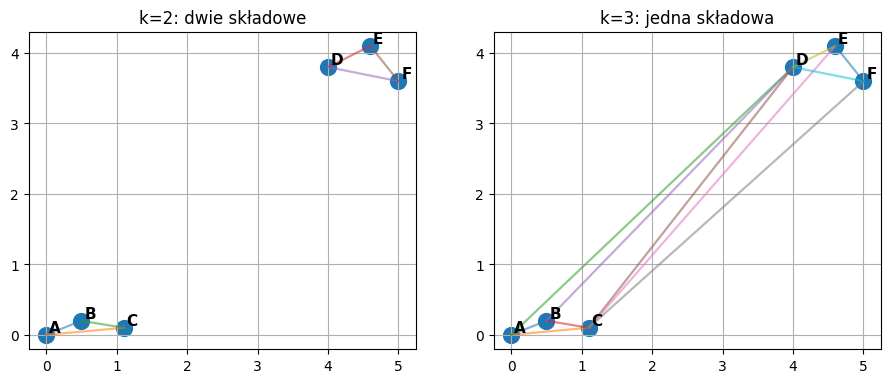

In [9]:
def connected_components(A):
    # Zwraca listę składowych spójnych grafu nieskierowanego.
    A = np.asarray(A, dtype=int)
    n = A.shape[0]
    visited = np.zeros(n, dtype=bool)
    components = []

    for start in range(n):
        if visited[start]:
            continue
        stack = [start]
        visited[start] = True
        comp = []
        while stack:
            v = stack.pop()
            comp.append(v)
            neighbors = np.where(A[v] == 1)[0]
            for nb in neighbors:
                if not visited[nb]:
                    visited[nb] = True
                    stack.append(nb)
        components.append(sorted(comp))
    return components


def components_df(A, labels):
    comps = connected_components(A)
    rows = []
    for idx, comp in enumerate(comps, start=1):
        rows.append({
            'składowa': idx,
            'wierzchołki': ', '.join(labels[comp]),
            'liczba wierzchołków': len(comp)
        })
    return pd.DataFrame(rows)

for name, A in [('union, k=2', A_k2), ('union, k=3', A_k3)]:
    display(Markdown(f'### Składowe spójne: {name}'))
    display(components_df(A, labels))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
plot_graph(X, labels, A_k2, title='k=2: dwie składowe', ax=axes[0])
plot_graph(X, labels, A_k3, title='k=3: jedna składowa', ax=axes[1])
plt.show()


### Minićwiczenie 4 — składowe spójne

1. Ile składowych spójnych ma graf dla $k=2$?
2. Ile składowych spójnych ma graf dla $k=3$?
3. Co zmieniło się geometrycznie?


### Rozwiązanie minićwiczenia 4

1. Dla $k=2$ graf ma dwie składowe: `A,B,C` oraz `D,E,F`.
2. Dla $k=3$ graf ma jedną składową.
3. Pojawiły się krawędzie-mosty między grupami.

Wniosek:

> Zmiana parametru $k$ może zmienić topologię grafu: z dwóch oddzielnych części zrobić jedną spójną strukturę.


## 5. Odległość grafowa

W danych geometrycznych odległość oznacza zwykle odległość euklidesową:

$$
d(x_i,x_j).
$$

W grafie możemy mierzyć inną odległość: **liczbę krawędzi na najkrótszej ścieżce**.

Oznaczmy ją:

$$
d_G(i,j).
$$

Przykład:

```text
A -- B -- C
```

Wtedy:

$$
d_G(A,C)=2.
$$

Jeśli między punktami nie ma ścieżki, zapisujemy:

$$
d_G(i,j)=\infty.
$$


In [10]:
def shortest_path_lengths_from(A, start):
    # Odległości grafowe od jednego startu, liczone BFS-em.
    A = np.asarray(A, dtype=int)
    n = A.shape[0]
    dist = np.full(n, np.inf)
    dist[start] = 0
    queue = [start]
    head = 0
    while head < len(queue):
        v = queue[head]
        head += 1
        for nb in np.where(A[v] == 1)[0]:
            if np.isinf(dist[nb]):
                dist[nb] = dist[v] + 1
                queue.append(nb)
    return dist


def all_pairs_shortest_paths(A):
    A = np.asarray(A, dtype=int)
    return np.vstack([shortest_path_lengths_from(A, i) for i in range(A.shape[0])])

SP_k2 = all_pairs_shortest_paths(A_k2)
SP_k3 = all_pairs_shortest_paths(A_k3)

display(Markdown('### Odległości grafowe dla k=2'))
display(format_matrix_for_display(SP_k2, labels, number_format='.0f'))

display(Markdown('### Odległości grafowe dla k=3'))
display(format_matrix_for_display(SP_k3, labels, number_format='.0f'))


### Odległości grafowe dla k=2

,A,B,C,D,E,F
A,0,1,1,∞,∞,∞
B,1,0,1,∞,∞,∞
C,1,1,0,∞,∞,∞
D,∞,∞,∞,0,1,1
E,∞,∞,∞,1,0,1
F,∞,∞,∞,1,1,0


### Odległości grafowe dla k=3

,A,B,C,D,E,F
A,0,1,1,1,2,2
B,1,0,1,1,2,2
C,1,1,0,1,1,1
D,1,1,1,0,1,1
E,2,2,1,1,0,1
F,2,2,1,1,1,0


### Minićwiczenie 5 — odległość po grafie

Porównaj punkty `A` oraz `F`.

1. Czy dla $k=2$ istnieje ścieżka z `A` do `F`?
2. Czy dla $k=3$ istnieje ścieżka z `A` do `F`?
3. Dlaczego odległość euklidesowa i grafowa mówią o czymś innym?


### Rozwiązanie minićwiczenia 5

1. Dla $k=2$ nie ma ścieżki z `A` do `F`, więc:

$$
d_G(A,F)=\infty.
$$

2. Dla $k=3$ graf jest spójny, więc ścieżka istnieje.

3. Odległość euklidesowa mówi, jak daleko punkty leżą w przestrzeni. Odległość grafowa mówi, ile kroków po sąsiedztwach trzeba wykonać, żeby przejść z jednego punktu do drugiego.

To jest ważne w manifold learningu: czasem struktura lokalnych przejść jest ważniejsza niż jedna globalna odległość w przestrzeni wejściowej.


## 6. Lokalne klastrowanie: czy sąsiedzi są też sąsiadami?

Stopień mówi tylko, ilu mamy sąsiadów.

Ale możemy zapytać mocniej:

> Czy moi sąsiedzi są połączeni między sobą?

To mierzy **lokalny współczynnik klasteryzacji**.

Dla wierzchołka $i$:

$$
C_i=\frac{\text{liczba krawędzi między sąsiadami } i}{\text{maksymalna możliwa liczba takich krawędzi}}.
$$

Równoważnie, jeśli $\deg(i)\ge 2$:

$$
C_i=\frac{2T_i}{\deg(i)(\deg(i)-1)},
$$

gdzie $T_i$ to liczba krawędzi między sąsiadami punktu $i$.

Interpretacja:

- $C_i=1$ — sąsiedzi tworzą zwartą grupę,
- $C_i=0$ — sąsiedzi nie są połączeni między sobą.


In [11]:
def local_clustering_coefficients(A):
    A = np.asarray(A, dtype=int)
    n = A.shape[0]
    coeffs = np.zeros(n, dtype=float)
    triangles_edges = np.zeros(n, dtype=int)

    for i in range(n):
        neigh = np.where(A[i] == 1)[0]
        deg = len(neigh)
        if deg < 2:
            coeffs[i] = 0.0
            triangles_edges[i] = 0
            continue
        sub = A[np.ix_(neigh, neigh)]
        edges_between_neighbors = int(np.triu(sub, 1).sum())
        triangles_edges[i] = edges_between_neighbors
        coeffs[i] = (2 * edges_between_neighbors) / (deg * (deg - 1))
    return coeffs, triangles_edges


def clustering_table(A, labels):
    degrees = A.sum(axis=1).astype(int)
    coeffs, neighbor_edges = local_clustering_coefficients(A)
    return pd.DataFrame({
        'punkt': labels,
        'stopień': degrees,
        'krawędzie między sąsiadami': neighbor_edges,
        'C_i': np.round(coeffs, 3)
    })

for name, A in [('union, k=2', A_k2), ('union, k=3', A_k3)]:
    display(Markdown(f'### Lokalne klastrowanie: {name}'))
    display(clustering_table(A, labels))


### Lokalne klastrowanie: union, k=2

,punkt,stopień,krawędzie między sąsiadami,C_i
0,A,2,1,1.0
1,B,2,1,1.0
2,C,2,1,1.0
3,D,2,1,1.0
4,E,2,1,1.0
5,F,2,1,1.0


### Lokalne klastrowanie: union, k=3

,punkt,stopień,krawędzie między sąsiadami,C_i
0,A,3,3,1.0
1,B,3,3,1.0
2,C,5,6,0.6
3,D,5,6,0.6
4,E,3,3,1.0
5,F,3,3,1.0


### Minićwiczenie 6 — klastrowanie lokalne

Dla grafu `union` przy $k=2$ mamy dwa trójkąty: `A-B-C` oraz `D-E-F`.

1. Jaki będzie lokalny współczynnik klasteryzacji $C_A$?
2. Dlaczego?
3. Co oznaczałoby $C_i=0$?


### Rozwiązanie minićwiczenia 6

1. Dla punktu `A` współczynnik wynosi:

$$
C_A=1.
$$

2. Punkt `A` ma dwóch sąsiadów: `B` i `C`. Te dwa punkty są również połączone między sobą. Sąsiedztwo punktu `A` jest więc maksymalnie domknięte.

3. Wartość $C_i=0$ oznacza, że sąsiedzi punktu $i$ nie mają połączeń między sobą. To jest bardziej struktura drzewiasta niż zwarta grupa.


## 7. Lokalne kule grafowe i intuicja wymiaru

W geometrii ciągłej możemy pytać:

> Ile punktów mieści się w promieniu $r$?

W grafie robimy coś podobnego, ale promień liczony jest liczbą kroków po krawędziach.

Definiujemy kulę grafową:

$$
B_G(i,r)=\{j: d_G(i,j)\le r\}.
$$

Liczba punktów w tej kuli:

$$
N_i(r)=|B_G(i,r)|.
$$

Intuicja:

- na linii wzrost jest mniej więcej liniowy,
- w drzewie z rozgałęzieniami wzrost może być bardzo szybki,
- w zwartej kliki wzrost od razu się nasyca.

To nie jest jeszcze formalny estymator wymiaru. To jest intuicja, że graf ma lokalną geometrię.


,centrum,r,N_i(r)
0,A,0,1
1,A,1,4
2,A,2,6
3,A,3,6
4,A,4,6
5,C,0,1
6,C,1,6
7,C,2,6
8,C,3,6
9,C,4,6


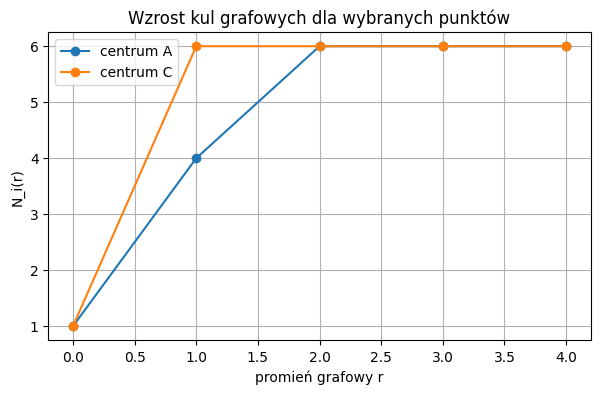

In [12]:
def ball_growth(A, labels, centers=None, max_radius=4):
    A = np.asarray(A, dtype=int)
    SP = all_pairs_shortest_paths(A)
    if centers is None:
        centers = range(A.shape[0])
    rows = []
    for i in centers:
        for r in range(max_radius + 1):
            count = int(np.sum(SP[i] <= r))
            rows.append({
                'centrum': labels[i],
                'r': r,
                'N_i(r)': count
            })
    return pd.DataFrame(rows)

# Porównajmy wzrost kul dla A i C w grafie k=3.
growth_df = ball_growth(A_k3, labels, centers=[0, 2], max_radius=4)
display(growth_df)

fig, ax = plt.subplots(figsize=(7, 4))
for center in growth_df['centrum'].unique():
    sub = growth_df[growth_df['centrum'] == center]
    ax.plot(sub['r'], sub['N_i(r)'], marker='o', label=f'centrum {center}')
ax.set_xlabel('promień grafowy r')
ax.set_ylabel('N_i(r)')
ax.set_title('Wzrost kul grafowych dla wybranych punktów')
ax.legend()
plt.show()


### Minićwiczenie 7 — wzrost kul

Spójrz na tabelę i wykres.

1. Co oznacza $N_A(0)$?
2. Co oznacza $N_A(1)$?
3. Co oznacza moment, w którym $N_A(r)$ przestaje rosnąć?


### Rozwiązanie minićwiczenia 7

1. $N_A(0)$ oznacza liczbę punktów w odległości grafowej $0$ od `A`. To jest tylko sam punkt `A`, więc zwykle $N_A(0)=1$.

2. $N_A(1)$ oznacza liczbę punktów osiągalnych z `A` w co najwyżej jednym kroku: `A` plus jego bezpośredni sąsiedzi.

3. Jeśli $N_A(r)$ przestaje rosnąć, to znaczy, że z punktu `A` dotarliśmy już do całej jego składowej spójnej.


## 8. Trzy prototypy geometrii grafu

Teraz zrobimy małe porównanie.

Nie liczymy jeszcze formalnej krzywizny dyskretnej, ale budujemy intuicję.

Porównamy trzy grafy:

1. **klikę** — bardzo zwarta struktura,
2. **cykl** — struktura bardziej „płaska”,
3. **gwiazdę** — struktura drzewiasta, z silnym rozgałęzieniem.

Intuicyjnie:

- klika ma dużo trójkątów i wysokie klastrowanie,
- cykl ma lokalnie podobną liczbę sąsiadów, ale brak trójkątów,
- gwiazda ma centrum i wiele liści, ale liście nie są połączone między sobą.


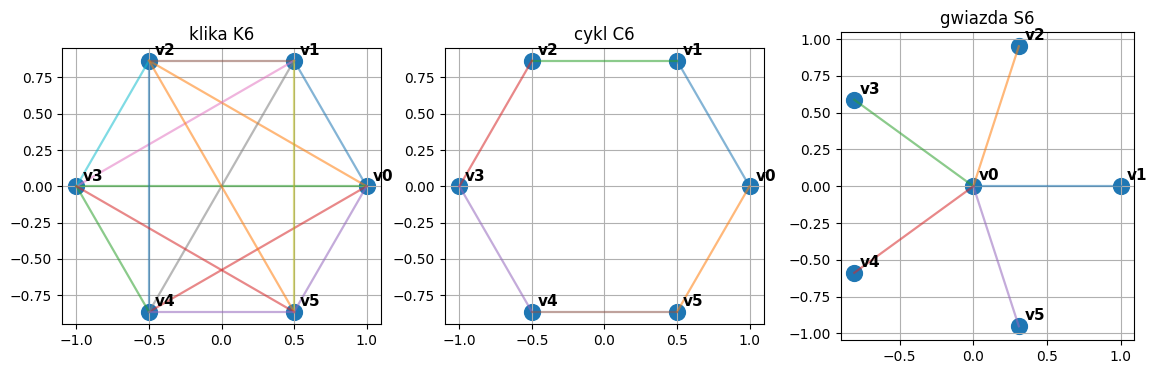

,graf,liczba krawędzi,średni stopień,średnie C_i,liczba składowych
0,klika K6,15,5.000,1.0,1
1,cykl C6,6,2.000,0.0,1
2,gwiazda S6,5,1.667,0.0,1


In [13]:
def make_clique(n):
    A = np.ones((n, n), dtype=int) - np.eye(n, dtype=int)
    return A


def make_cycle(n):
    A = np.zeros((n, n), dtype=int)
    for i in range(n):
        A[i, (i - 1) % n] = 1
        A[i, (i + 1) % n] = 1
    return A


def make_star(n):
    A = np.zeros((n, n), dtype=int)
    for i in range(1, n):
        A[0, i] = 1
        A[i, 0] = 1
    return A


def circle_positions(n, radius=1.0):
    angles = np.linspace(0, 2*np.pi, n, endpoint=False)
    return np.c_[radius*np.cos(angles), radius*np.sin(angles)]

n_proto = 6
labels_proto = np.array([f'v{i}' for i in range(n_proto)])
X_circle = circle_positions(n_proto)
X_star = X_circle.copy()
X_star[0] = [0, 0]
X_star[1:] = circle_positions(n_proto - 1, radius=1.0)

proto_graphs = {
    'klika K6': (make_clique(n_proto), X_circle),
    'cykl C6': (make_cycle(n_proto), X_circle),
    'gwiazda S6': (make_star(n_proto), X_star),
}

summary_rows = []
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (name, (A_proto, X_proto)) in zip(axes, proto_graphs.items()):
    coeffs, _ = local_clustering_coefficients(A_proto)
    degrees = A_proto.sum(axis=1)
    plot_graph(X_proto, labels_proto, A_proto, title=name, ax=ax)
    summary_rows.append({
        'graf': name,
        'liczba krawędzi': int(np.triu(A_proto, 1).sum()),
        'średni stopień': float(np.round(degrees.mean(), 3)),
        'średnie C_i': float(np.round(coeffs.mean(), 3)),
        'liczba składowych': len(connected_components(A_proto))
    })

plt.show()
display(pd.DataFrame(summary_rows))


### Minićwiczenie 8 — intuicja krzywizny

Bez liczenia formalnej krzywizny spróbuj odpowiedzieć:

1. Który graf jest najbardziej zwarty?
2. Który graf jest najbardziej drzewiasty?
3. Który graf ma najwyższe lokalne klastrowanie?
4. Który graf ma lokalne klastrowanie równe zero, mimo że jest spójny?


### Rozwiązanie minićwiczenia 8

1. Najbardziej zwarta jest klika $K_6$, bo każdy punkt jest połączony z każdym.
2. Najbardziej drzewiasta jest gwiazda, bo ma centrum i liście, ale liście nie są połączone między sobą.
3. Najwyższe lokalne klastrowanie ma klika.
4. Gwiazda i cykl mają lokalne klastrowanie równe zero w tym przykładzie, bo sąsiedzi danego punktu nie są połączeni między sobą.

Uwaga interpretacyjna:

- wysoka liczba trójkątów sugeruje lokalną zwartość,
- brak trójkątów i silne rozgałęzienia sugerują strukturę bardziej drzewiastą,
- to jest intuicja prowadząca do krzywizny dyskretnej, ale nie jest jeszcze formalną definicją.


## 9. Panel interaktywny: jak $k$ zmienia topologię grafu?

Poniższa komórka buduje panel Plotly z suwakiem $k$.

Warto obserwować trzy rzeczy:

1. liczbę krawędzi,
2. liczbę składowych spójnych,
3. moment, w którym dwie lokalne grupy stają się jednym grafem.

To jest najważniejsze przesłanie tego notebooka:

> Parametr sąsiedztwa zmienia geometrię i topologię grafu, a nie tylko wygląd wykresu.


In [14]:
from IPython.display import display, Markdown
display(Markdown('Panel interaktywny jest zapisany jako `html/0_2_panel_k_topologia_grafu.html`. W wersji źródłowej notebooka jest pełna komórka generująca panel.'))

Panel interaktywny jest zapisany jako `html/0_2_panel_k_topologia_grafu.html`. W wersji źródłowej notebooka jest pełna komórka generująca panel.

## 10. Co zapamiętać?

W `0_1` nauczyliśmy się budować graf.

W tym notebooku nauczyliśmy się czytać graf.

Najważniejsze obiekty:

| Obiekt | Pytanie |
|---|---|
| stopień $\deg(i)$ | ilu sąsiadów ma punkt? |
| liczba krawędzi $|E|$ | jak gęsty jest graf? |
| składowe spójne | ile oddzielnych części ma graf? |
| odległość grafowa $d_G(i,j)$ | ile kroków trzeba przejść po grafie? |
| klastrowanie lokalne $C_i$ | czy sąsiedzi punktu są też sąsiadami? |
| kula grafowa $B_G(i,r)$ | jak szybko rośnie lokalne otoczenie? |

Główna idea:

```text
punkty
↓
macierz odległości
↓
macierz sąsiedztwa
↓
graf
↓
własności grafu
↓
UMAP / DBSCAN / spectral clustering / GNN
```


## 11. Co dalej?

Ten notebook jest pomostem do kilku kolejnych tematów.

### DBSCAN

DBSCAN można rozumieć jako pracę na grafie $\varepsilon$-sąsiedztwa z dodatkowym warunkiem gęstości.

### UMAP

UMAP buduje ważony graf sąsiedztwa i próbuje zachować jego strukturę w niższym wymiarze.

### Spectral Clustering

Spectral clustering używa macierzy sąsiedztwa i Laplasjanu grafu.

### GNN

Graph Neural Networks propagują informacje po krawędziach grafu.

### Krzywizna dyskretna

Formalna krzywizna dyskretna, np. Ollivier-Ricci albo Forman-Ricci, wymaga osobnego notebooka. Tutaj zbudowaliśmy intuicję przez:

- stopień,
- składowe,
- odległości grafowe,
- klastrowanie,
- wzrost kul grafowych.

To wystarczy jako pierwsza baza pod manifold learning i geometrię embeddingów.
